In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense


In [2]:
# Load the 2-hour interval CSV
df = pd.read_csv("traffic_2hr_intervals.csv", parse_dates=["datetime"])

# Sort by location and datetime
df.sort_values(by=["location", "datetime"], inplace=True)

# Select one location for modeling
location_id = df["location"].unique()[0]  # you can change this to try others
df_location = df[df["location"] == location_id]


In [3]:
# Define the input features
features = ['flow', 'occupy', 'speed']

# Use MinMaxScaler
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df_location[features])

# Create scaled DataFrame
scaled_df = pd.DataFrame(scaled_data, columns=features)
scaled_df['datetime'] = df_location['datetime'].values


In [4]:
# Function to create input-output sequences
def create_sequences(data, target_col, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data.iloc[i:i+seq_len][features].values)
        y.append(data.iloc[i+seq_len][target_col])
    return np.array(X), np.array(y)

# Sequence length = 24 (i.e., 2 full days at 2hr intervals)
sequence_length = 24
X, y = create_sequences(scaled_df, target_col='flow', seq_len=sequence_length)



In [6]:
split_index = int(len(X) * 0.8)

X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]


In [7]:
# Build GRU model
model = Sequential()
model.add(GRU(units=64, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dense(1))  # Predicting one value (flow)

# Compile
model.compile(optimizer='adam', loss='mae')

# Train
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=32
)


Epoch 1/20


c:\Users\mayan\OneDrive\Desktop\PRJ 2\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.2956 - val_loss: 0.2098
Epoch 2/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2051 - val_loss: 0.1793
Epoch 3/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1658 - val_loss: 0.1515
Epoch 4/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1499 - val_loss: 0.1294
Epoch 5/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1249 - val_loss: 0.1179
Epoch 6/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1183 - val_loss: 0.1196
Epoch 7/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1162 - val_loss: 0.1085
Epoch 8/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1146 - val_loss: 0.1040
Epoch 9/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1074 - val_loss: 0.0998
Epoch 10/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0975 - val_loss: 0.1016
Epoch 11/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0955 - val_loss: 0.0947
Epoch 12/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0875 - val_loss

In [8]:
y_pred = model.predict(X_test)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


In [10]:
# Index of flow in feature list
flow_index = features.index("flow")

# Rebuild arrays for inverse scaling
inv_y_pred = scaler.inverse_transform(
    np.concatenate([y_pred, X_test[:, -1, 1:]], axis=1)
)[:, flow_index]

inv_y_test = scaler.inverse_transform(
    np.concatenate([y_test.reshape(-1, 1), X_test[:, -1, 1:]], axis=1)
)[:, flow_index]


In [11]:
mae = mean_absolute_error(inv_y_test, inv_y_pred)
print(f"GRU Model MAE: {mae:.3f}")


GRU Model MAE: 37.648


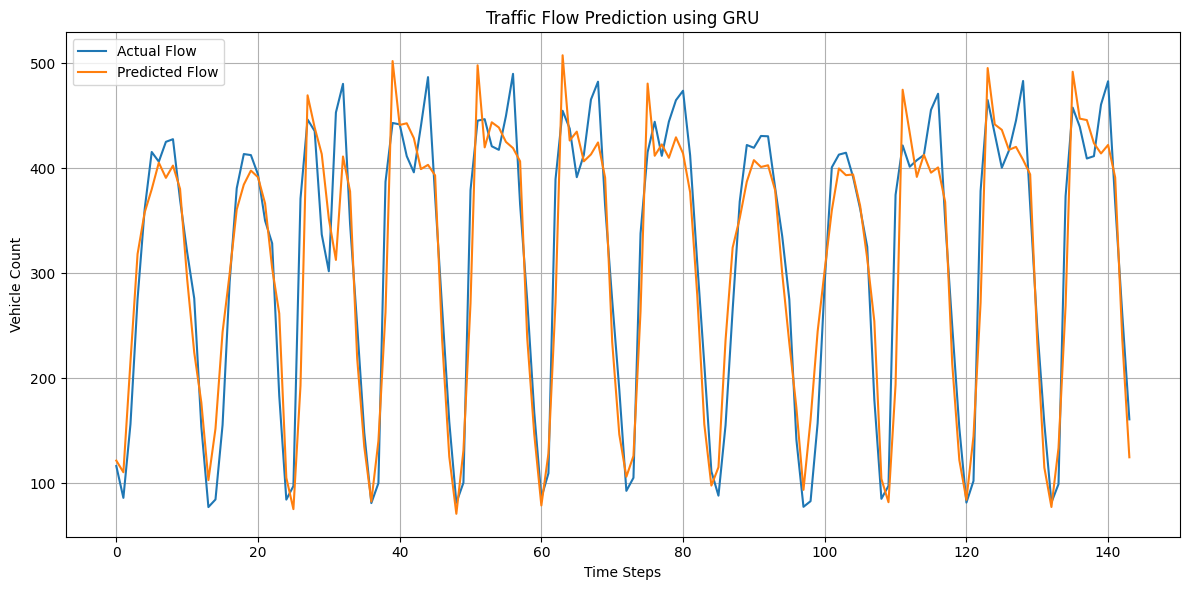

In [12]:
plt.figure(figsize=(12, 6))
plt.plot(inv_y_test[:200], label='Actual Flow')
plt.plot(inv_y_pred[:200], label='Predicted Flow')
plt.title('Traffic Flow Prediction using GRU')
plt.xlabel('Time Steps')
plt.ylabel('Vehicle Count')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
